Vamos a empezar sacando el porcentaje de ISMs de cada transcrito y luego tendremos que colapsar

In [265]:
import pandas as pd
import polars as pl
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

Como la tabla que tenemos no está agrupada a nivel de transcrito (sino a nivel de combinacion de muestra, transcrito y numero de exones cubiertos), tenemos que hacer algunos cambios en la tabla

In [266]:
# Cargamos la tabla y apuntamos en una columna en cuántas muestras aparece cada transcrito
mt = pd.read_csv("../megatabla_7.tsv", sep = "\t")
mt["RIN_TS"] = mt["RIN"].astype(str) + mt["TS"].astype(str)
rin_ts_combs = mt[["RIN_TS"]].drop_duplicates()
n_combs = mt.drop_duplicates(["associated_transcript", "RIN_TS"]).groupby("associated_transcript").size()
mt["n_combs"] = mt["associated_transcript"].map(n_combs)
n_combs_max = mt["n_combs"].max()

# Trabajamos sobre una copia de mt
mt_filt = mt.copy()
# Nos guardamos el numero de counts total por transcrito y muestra
total_counts = mt_filt.groupby(['associated_transcript', 'RIN_TS'])['counts'].sum().reset_index(name='total_transcript_counts')
# Contamos el número de reads asignadas como ISM
ism_counts = mt_filt[mt_filt['structural_category'] == 'incomplete-splice_match'].groupby(['associated_transcript', 'RIN_TS'])['counts'].sum().reset_index(name='ism_counts')
# Se lo añadimos a la tabla con los counts y sacamos el porcentaje de ISMs
ISMs = pd.merge(total_counts, ism_counts, on=['associated_transcript', 'RIN_TS'], how='left')
ISMs['ism_counts'] = ISMs['ism_counts'].fillna(0) # Si no hay ISMs, es 0
ISMs['porc_ISM'] = (ISMs['ism_counts'] / ISMs['total_transcript_counts']) * 100
# Como la tabla no está agrupada por transcritos tenemos que promediar las columnas que dependen de el conjunto transcrito_muestra_numero de exones cubiertos
# Y dejar las estáticas como están
cols_estaticas = ['associated_gene','associated_transcript', 'ref_length', 'ref_exons', 
                  'strand','counts_transcript','TS', 'RIN', 
                  'seqbatch', 'time','dip_test_TSS', 'dip_test_TSS_pval',
                  'exon_junction_density', 'porc_GC', 'CPM_transcript',
                  'length_CDS', 'porc_GC_CDS', 'length_3pUTR', 'porc_GC_3pUTR',
                  'length_5pUTR', 'porc_GC_5pUTR', 'RIN_TS', 'n_combs']
mt_estatico = mt_filt[cols_estaticas].drop_duplicates(subset=["associated_transcript","RIN_TS"])
ISMs = pd.merge(ISMs, mt_estatico, on=['associated_transcript','RIN_TS'], how='left')
# Esto para las dinámicas
cols_dinamicas = ['length','diff_to_gene_TSS','diff_to_gene_TTS','CV_diff_to_gene_TSS',
                  'CV_diff_to_gene_TTS','Cov_D1','Cov_D2', 'Cov_D3',
                  'Cov_D4', 'Cov_D5', 'Cov_D6', 'Cov_D7', 
                  'Cov_D8', 'Cov_D9','Cov_D10']
# Para cada columna de la que queremos sacar la media ponderada
for col in cols_dinamicas:
       mt_filt[f'{col}_ponderada'] = mt_filt[col]*mt_filt["counts"]
# Sacaremos una columna que sea la media ponderada por columna
instrucciones = {f'{col}_ponderada' :'sum' for col in cols_dinamicas}
instrucciones["counts"] = 'sum'
# Agregamos y dividimos por los counts
dinamicas_grouped = mt_filt.groupby(["associated_transcript","RIN_TS"]).agg(instrucciones).reset_index()
for col in cols_dinamicas:
    dinamicas_grouped[f'avg_{col}'] = dinamicas_grouped[f'{col}_ponderada'] / dinamicas_grouped['counts']
# Y ya nos quedamos con el dataframe final 
cols_finales = ['associated_transcript', 'RIN_TS', 'counts'] + [f'avg_{col}' for col in cols_dinamicas]
df_dinamicas_limpio = dinamicas_grouped[cols_finales]
df_dinamicas_limpio.rename(columns={'counts': 'total_counts'}, inplace=True)
df_final = pd.merge(ISMs,df_dinamicas_limpio, on=["associated_transcript","RIN_TS"], how="left")
df_final['strand'] = df_final['strand'].map({'+': 1, '-': 0}) # pasamos strand a un dummy numérico


C:\Users\Andres\AppData\Local\Temp\ipykernel_10740\3870001079.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dinamicas_limpio.rename(columns={'counts': 'total_counts'}, inplace=True)


Ahora ya podemos empezar sacando los conjuntos de entrenamiento y los dos de testeo.

In [267]:
cols_drop = ["associated_transcript", "associated_gene", "RIN_TS","porc_ISM","ism_counts","seqbatch","time","n_combs","total_counts","TS"]


X_train = df_final[(df_final["RIN"] != 9.9) & (df_final["n_combs"] == n_combs_max)].drop(columns=cols_drop)
y_train = df_final[(df_final["RIN"] != 9.9) & (df_final["n_combs"] == n_combs_max)]["porc_ISM"]

# Test 1: Transcritos de RIN 9.9 que estaban en el set de entrenamiento
X_test_vistos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] == n_combs_max)].drop(columns=cols_drop)
y_test_vistos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] == n_combs_max)]["porc_ISM"]

# Test 2: Transcritos de RIN 9.9 NUEVOS (no estaban en todas las muestras)
X_test_nuevos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] < n_combs_max)].drop(columns=cols_drop)
y_test_nuevos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] < n_combs_max)]["porc_ISM"]

El entrenamiento lo hicimos en garnatxa, cargamos el modelo asi:

In [268]:
import joblib

# Cargamos el modelo desde el archivo
mejor_modelo = joblib.load('../mejor_modelo_ism.pkl') # cambiar a mejor_modelo_ism_codons para probar con esemodelo

c:\Users\Andres\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Andres\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Mostramos los errores y R cuadrados y ploteamos la relacion entre prediccion y realidad.


--- TEST: TRANSCRITOS QUE YA ESTABAN EN EL TRAINING SET
MAE: 6.125199508214483
RMSE: 126.6747940647052
R²: 0.9280807891349899

--- TEST: TRANSCRITOS QUE NO ESTABAN EN EL TRAINING SET
MAE: 14.51254261833341
RMSE: 586.2168589177257
R²: 0.7364378164405867


Text(0.5, 0.98, 'Model performance: Prediction vs Reality')

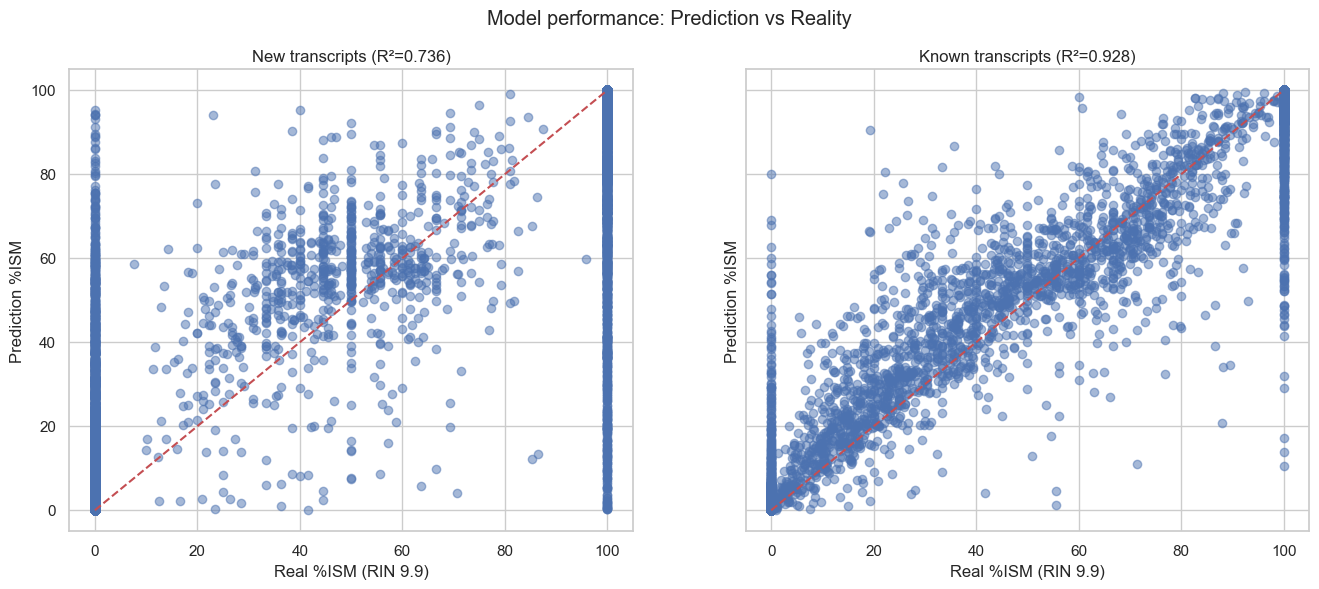

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

predicciones_vistos = mejor_modelo.predict(X_test_vistos)
print("\n--- TEST: TRANSCRITOS QUE YA ESTABAN EN EL TRAINING SET")
print("MAE:", mean_absolute_error(y_test_vistos, predicciones_vistos))
print("RMSE:", mean_squared_error(y_test_vistos, predicciones_vistos))
print("R²:", r2_score(y_test_vistos, predicciones_vistos))

predicciones_nuevos = mejor_modelo.predict(X_test_nuevos)
print("\n--- TEST: TRANSCRITOS QUE NO ESTABAN EN EL TRAINING SET")
print("MAE:", mean_absolute_error(y_test_nuevos, predicciones_nuevos))
print("RMSE:", mean_squared_error(y_test_nuevos, predicciones_nuevos))
print("R²:", r2_score(y_test_nuevos, predicciones_nuevos))

# Unimos las predicciones a los DF originales
df_resultados_vistos = X_test_vistos.copy()
df_resultados_vistos['porc_ISM_real'] = y_test_vistos
df_resultados_vistos['prediccion'] = predicciones_vistos

df_resultados_nuevos = X_test_nuevos.copy()
df_resultados_nuevos['porc_ISM_real'] = y_test_nuevos
df_resultados_nuevos['prediccion'] = predicciones_nuevos

# Ploteamos las figuras
n=0
for ax, i in zip(axes,[(y_test_nuevos,predicciones_nuevos),(y_test_vistos,predicciones_vistos)]):
    ax.scatter(i[0], i[1], alpha=0.5)
    ax.plot([i[0].min(), i[0].max()], [i[0].min(), i[0].max()], 'r--')
    ax.set_xlabel("Real %ISM (RIN 9.9)")
    ax.set_ylabel("Prediction %ISM")
    ax.set_title(f"New transcripts (R²={r2_score(y_test_nuevos, predicciones_nuevos):.3f})" if n==0 
                 else f"Known transcripts (R²={r2_score(y_test_vistos, predicciones_vistos):.3f})")
    n+=1
fig.suptitle("Model performance: Prediction vs Reality")


Ahora podemos sacar las importancias de las features y plotearlo

--- FEATURE IMPORTANCES ---
                    Feature  Importance
18     avg_diff_to_gene_TSS    0.381308
2                 ref_exons    0.174420
20  avg_CV_diff_to_gene_TSS    0.126182
8     exon_junction_density    0.062983
11               length_CDS    0.033942
17               avg_length    0.028934
23               avg_Cov_D2    0.025472
6              dip_test_TSS    0.015929
15             length_5pUTR    0.014303
1                ref_length    0.013176
13             length_3pUTR    0.012372
7         dip_test_TSS_pval    0.012158
9                   porc_GC    0.010455
14            porc_GC_3pUTR    0.010110
22               avg_Cov_D1    0.008943
16            porc_GC_5pUTR    0.008702
24               avg_Cov_D3    0.007232
19     avg_diff_to_gene_TTS    0.007023
12              porc_GC_CDS    0.006271
5                       RIN    0.005513
31              avg_Cov_D10    0.005318
10           CPM_transcript    0.005101
25               avg_Cov_D4    0.003507
26          

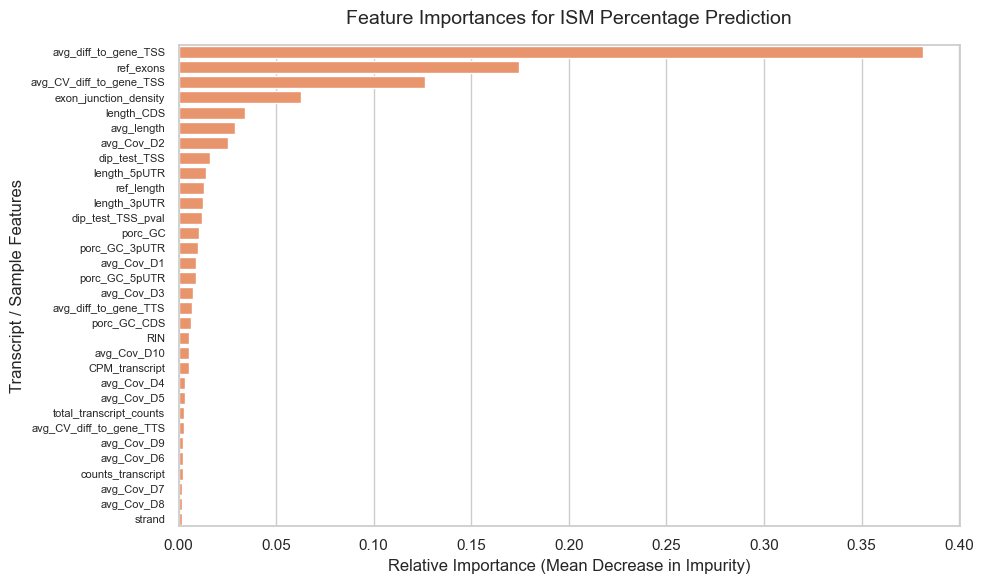

In [270]:

importancias = mejor_modelo.feature_importances_
nombres_columnas = X_test_vistos.columns

# Creamos un df y lo ordenamos por Importance
df_importancias = pd.DataFrame({
    'Feature': nombres_columnas,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

# Printeamos las importancias por pantalla
print("--- FEATURE IMPORTANCES ---")
print(df_importancias)

# Empezamos con el plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importancias, 
    color="#fc8d59" 
)
plt.yticks(fontsize=8)
plt.title('Feature Importances for ISM Percentage Prediction', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Transcript / Sample Features', fontsize=12)
plt.tight_layout()
plt.show()

Podemos plotear tambien el recorrido de optimización con optuna

Text(0.5, 1.0, 'Optuna hyperparameter search')

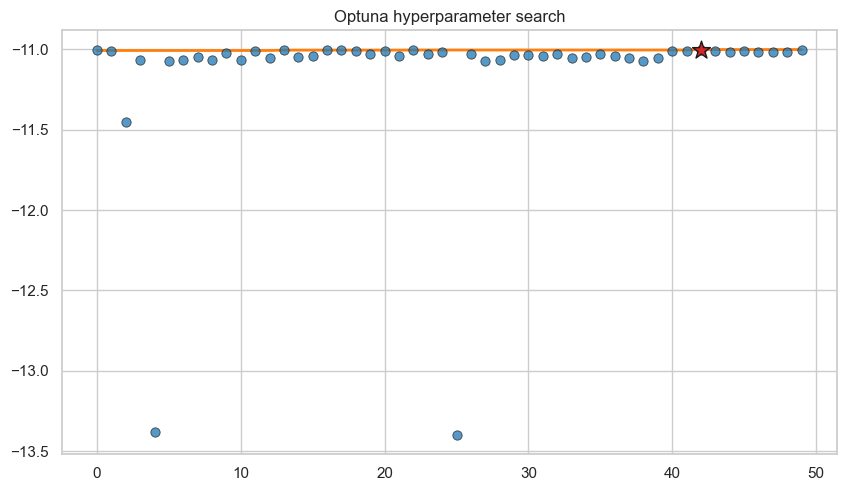

In [271]:
optuna_hist = pd.read_csv("../optuna_optimization_history.csv")
optuna_hist.sort_values(by="best_value")
fig, ax = plt.subplots(figsize=(10, 5.5))

# Plotear todos los trials individuales (puntos azules)
ax.scatter(
    optuna_hist["trial_number"],
    optuna_hist["value"],
    color="#1f77b4",
    alpha=0.75,
    edgecolors="k",
    linewidths=0.6,
    s=45,
    label="Objective Value",
    zorder=3,
)

# Plotear la línea del progreso del mejor valor (línea naranja)
ax.plot(
    optuna_hist["trial_number"],
    optuna_hist["best_value"],
    color="#ff7f0e",
    linestyle="-",
    linewidth=2,
    label="Best Value",
    zorder=2,
)

# Encontrar y destacar el mejor trial con una estrella roja grande
best_idx = optuna_hist["value"].idxmax()
best_trial = optuna_hist.loc[best_idx]
ax.scatter(
    best_trial["trial_number"],
    best_trial["value"],
    color="#d62728",
    s=180,
    marker="*",
    edgecolors="k",
    label=f"Best Trial (Trial {int(best_trial['trial_number'])})",
    zorder=4,
)
ax.set_title("Optuna hyperparameter search")

Despues de ver las importancias que asigna el modelo a cada columna y que predice peor entorno a los valores extremos de ISM, decidimos probar a ajustar un modelo lineal generalizado

In [272]:
columnas_top=df_importancias[df_importancias["Importance"]>= 0.01]["Feature"].to_list()

In [273]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

# Convertimos nuestro porcentaje a fraccion
y_train_frac = y_train / 100.0

# Ajustamos la fraccion para que llegue justo a 0 ni a 1
epsilon = 1e-6
y_train_frac = np.clip(y_train_frac, epsilon, 1 - epsilon)
# Estas son las columnas que vamos a probar
columnas_top=df_importancias[df_importancias["Importance"]>= 0.01]["Feature"].to_list()
columnas_top.append("RIN")
print(columnas_top)
# Nos quedamos con las columnas seleccionadas
df_glm_train = X_train[columnas_top].copy()
# Añadimos el y
df_glm_train['target_frac'] = y_train_frac

# Miramos si hay nulos
print("Valores nulos por columna antes de limpiar:")
print(df_glm_train.isna().sum())

# Vamos a rellenar los nulos como 0s
df_glm_train.fillna(0,inplace=True) 

# Volvemos a separar X e y ya limpios
X_train_clean = df_glm_train[columnas_top]
y_train_clean = df_glm_train['target_frac']
# ------------------------------

# 2. Añadimos la constante a la matriz X limpia
X_train_glm = sm.add_constant(X_train_clean)

# 3. Ajustamos el Modelo Lineal Generalizado
glm_model = sm.GLM(
    endog=y_train_clean, 
    exog=X_train_glm, 
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

# Imprimimos el resumen estadístico
print(glm_model.summary())

['avg_diff_to_gene_TSS', 'ref_exons', 'avg_CV_diff_to_gene_TSS', 'exon_junction_density', 'length_CDS', 'avg_length', 'avg_Cov_D2', 'dip_test_TSS', 'length_5pUTR', 'ref_length', 'length_3pUTR', 'dip_test_TSS_pval', 'porc_GC', 'porc_GC_3pUTR', 'RIN']
Valores nulos por columna antes de limpiar:
avg_diff_to_gene_TSS           0
ref_exons                      0
avg_CV_diff_to_gene_TSS        0
exon_junction_density          0
length_CDS                  9002
avg_length                     0
avg_Cov_D2                     0
dip_test_TSS                   0
length_5pUTR               10920
ref_length                     0
length_3pUTR                9730
dip_test_TSS_pval              0
porc_GC                        0
porc_GC_3pUTR               9730
RIN                            0
target_frac                    0
dtype: int64
                 Generalized Linear Model Regression Results                  
Dep. Variable:            target_frac   No. Observations:                71064
Model: 

Vemos que hay valores a los que el modelo no le da tanta importancia o significancia como esperamos, pudiendo indicar que la relacion no es lineal o son "moduladores". Vamos a comprobar las interacciones de los 6 primeros con todos los demás.

In [274]:
formula = "target_frac ~ "
for i in columnas_top[0:6]:
    for j in columnas_top:
        formula += i + f"*{j} +"
    
print(formula)



target_frac ~ avg_diff_to_gene_TSS*avg_diff_to_gene_TSS +avg_diff_to_gene_TSS*ref_exons +avg_diff_to_gene_TSS*avg_CV_diff_to_gene_TSS +avg_diff_to_gene_TSS*exon_junction_density +avg_diff_to_gene_TSS*length_CDS +avg_diff_to_gene_TSS*avg_length +avg_diff_to_gene_TSS*avg_Cov_D2 +avg_diff_to_gene_TSS*dip_test_TSS +avg_diff_to_gene_TSS*length_5pUTR +avg_diff_to_gene_TSS*ref_length +avg_diff_to_gene_TSS*length_3pUTR +avg_diff_to_gene_TSS*dip_test_TSS_pval +avg_diff_to_gene_TSS*porc_GC +avg_diff_to_gene_TSS*porc_GC_3pUTR +avg_diff_to_gene_TSS*RIN +ref_exons*avg_diff_to_gene_TSS +ref_exons*ref_exons +ref_exons*avg_CV_diff_to_gene_TSS +ref_exons*exon_junction_density +ref_exons*length_CDS +ref_exons*avg_length +ref_exons*avg_Cov_D2 +ref_exons*dip_test_TSS +ref_exons*length_5pUTR +ref_exons*ref_length +ref_exons*length_3pUTR +ref_exons*dip_test_TSS_pval +ref_exons*porc_GC +ref_exons*porc_GC_3pUTR +ref_exons*RIN +avg_CV_diff_to_gene_TSS*avg_diff_to_gene_TSS +avg_CV_diff_to_gene_TSS*ref_exons +av

In [275]:
formula = formula[:-1]
glm_model_final = smf.glm(
    formula=formula, 
    data=df_glm_train, 
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

Ajustamos el modelo con los que tengan un coeficiente mayor a 0.01

In [276]:
# Sacamos un DF resumen
df_results = pd.DataFrame({
    'coeficiente': glm_model_final.params,
    'p_value': glm_model_final.pvalues,
    'std_err': glm_model_final.bse
})

# Ordenamos por el coeficiente
df_sorted = df_results.iloc[df_results['coeficiente'].abs().argsort()[::-1]]

df_sorted.head(30)
coeficientes_top = df_sorted[df_sorted["coeficiente"].abs() >=0.01].index.to_list()

formula = "target_frac ~ "
for i in coeficientes_top:
    if i == "Intercept":
        continue
    formula += i + "+"
formula = formula[:-1]
glm_model_final = smf.glm(
    formula=formula, 
    data=df_glm_train, 
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

In [277]:
def evaluate_glm_matrices_clean(model, X_test, y_test_real, features):
    df_eval = X_test[features].copy()
    
    
    df_eval['target_real_perc'] = y_test_real 
    
    # Nos quitamos NaNs
    filas_antes = len(df_eval)
    df_eval.fillna(0,inplace=True)
    filas_despues = len(df_eval)
    
    if filas_antes != filas_despues:
        print(f" Se han eliminado {filas_antes - filas_despues} transcritos por contener NaNs.")
        
    # Separamos ahora que hemos quitado los Nans
    X_test_clean = df_eval[features]
    y_test_real_clean = df_eval['target_real_perc']
    
    # Añadimos constante porque sino daba fallos
    X_test_glm = sm.add_constant(X_test_clean, has_constant='add')
    
    # Predecimos con el modelo
    predictions_frac = model.predict(X_test_glm)
    
    # Convertimos prediccion a porcentaje para comparar
    predictions_perc = predictions_frac * 100.0
    
    
    mae = mean_absolute_error(y_test_real_clean, predictions_perc)
    rmse = np.sqrt(mean_squared_error(y_test_real_clean, predictions_perc))
    r2 = r2_score(y_test_real_clean, predictions_perc)
    
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2:   {r2:.3f}\n")
    
    return y_test_real_clean, predictions_perc

# Printeamos resultados para los dos 

print("--- GLM: Transcritos Vistos (RIN 9.9) ---")
real_vistos, pred_vistos = evaluate_glm_matrices_clean(
    glm_model_final, X_test_vistos, y_test_vistos, columnas_top
)

print("--- GLM: Transcritos Nuevos (RIN 9.9) ---")
real_nuevos, pred_nuevos = evaluate_glm_matrices_clean(
    glm_model_final, X_test_nuevos, y_test_nuevos, columnas_top
)

--- GLM: Transcritos Vistos (RIN 9.9) ---
  MAE:  22.28
  RMSE: 29.59
  R2:   0.503

--- GLM: Transcritos Nuevos (RIN 9.9) ---
  MAE:  26.99
  RMSE: 35.67
  R2:   0.428



Hacemos el scatterplot con el resultado

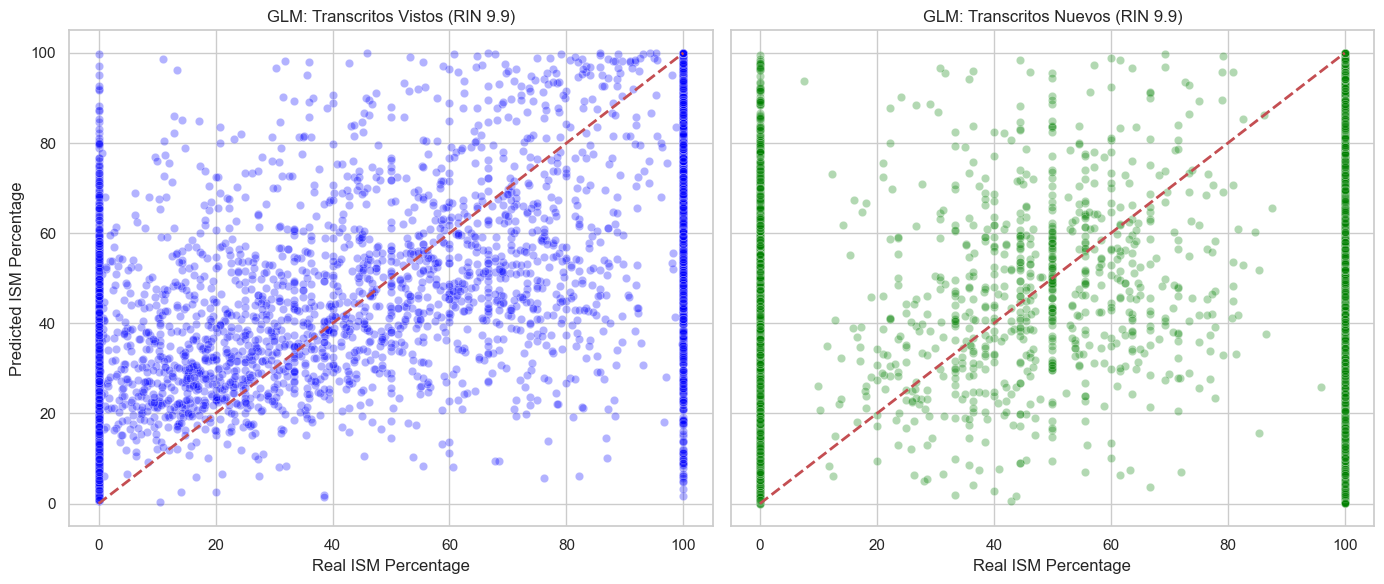

In [278]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot 1: Transcritos Vistos
sns.scatterplot(x=real_vistos, y=pred_vistos, alpha=0.3, color='blue', ax=axes[0])
axes[0].plot([0, 100], [0, 100], 'r--', lw=2) # Línea ideal (x=y)
axes[0].set_title('GLM: Transcritos Vistos (RIN 9.9)')
axes[0].set_xlabel('Real ISM Percentage')
axes[0].set_ylabel('Predicted ISM Percentage')

# Plot 2: Transcritos Nuevos
sns.scatterplot(x=real_nuevos, y=pred_nuevos, alpha=0.3, color='green', ax=axes[1])
axes[1].plot([0, 100], [0, 100], 'r--', lw=2) # Línea ideal (x=y)
axes[1].set_title('GLM: Transcritos Nuevos (RIN 9.9)')
axes[1].set_xlabel('Real ISM Percentage')

plt.tight_layout()
plt.show()

Con la tabla con codones hacemo algo muy parecido a lo de antes

In [279]:
mt = pd.read_csv("../megatabla_8.tsv", sep = "\t")

mt["RIN_TS"] = mt["RIN"].astype(str) + mt["TS"].astype(str)
rin_ts_combs = mt[["RIN_TS"]].drop_duplicates()
n_combs = mt.drop_duplicates(["associated_transcript", "RIN_TS"]).groupby("associated_transcript").size()
mt["n_combs"] = mt["associated_transcript"].map(n_combs)
n_combs_max = mt["n_combs"].max()
mt_filt = mt.copy()
total_counts = mt_filt.groupby(['associated_transcript', 'RIN_TS'])['counts'].sum().reset_index(name='total_transcript_counts')
ism_counts = mt_filt[mt_filt['structural_category'] == 'incomplete-splice_match'].groupby(['associated_transcript', 'RIN_TS'])['counts'].sum().reset_index(name='ism_counts')

ISMs = pd.merge(total_counts, ism_counts, on=['associated_transcript', 'RIN_TS'], how='left')
ISMs['ism_counts'] = ISMs['ism_counts'].fillna(0) # Si no hay ISMs, es 0
ISMs['porc_ISM'] = (ISMs['ism_counts'] / ISMs['total_transcript_counts']) * 100
cols_estaticas = ['associated_gene','associated_transcript', 'ref_length', 'ref_exons', 
                  'strand','counts_transcript','TS', 'RIN', 
                  'seqbatch', 'time','dip_test_TSS', 'dip_test_TSS_pval',
                  'exon_junction_density', 'porc_GC', 'CPM_transcript',
                  'length_CDS', 'porc_GC_CDS', 'length_3pUTR', 'porc_GC_3pUTR',
                  'length_5pUTR', 'porc_GC_5pUTR', 'RIN_TS', 'n_combs']
cols_codons=[]
for a in ["A","C","T","G"]:
    for b in ["A","C","T","G"]:
        for c in ["A","C","T","G"]:
            cols_codons.append(f"codon_{a}{b}{c}")
cols_estaticas.extend(cols_codons)
mt_estatico = mt_filt[cols_estaticas].drop_duplicates(subset=["associated_transcript","RIN_TS"])
ISMs = pd.merge(ISMs, mt_estatico, on=['associated_transcript','RIN_TS'], how='left')

cols_dinamicas = ['length','diff_to_gene_TSS','diff_to_gene_TTS','CV_diff_to_gene_TSS',
                  'CV_diff_to_gene_TTS','Cov_D1','Cov_D2', 'Cov_D3',
                  'Cov_D4', 'Cov_D5', 'Cov_D6', 'Cov_D7', 
                  'Cov_D8', 'Cov_D9','Cov_D10']
# Para cada columna de la que queremos sacar la media ponderada
for col in cols_dinamicas:
       mt_filt[f'{col}_ponderada'] = mt_filt[col]*mt_filt["counts"]
instrucciones = {f'{col}_ponderada' :'sum' for col in cols_dinamicas}
instrucciones["counts"] = 'sum'
dinamicas_grouped = mt_filt.groupby(["associated_transcript","RIN_TS"]).agg(instrucciones).reset_index()
for col in cols_dinamicas:
    dinamicas_grouped[f'avg_{col}'] = dinamicas_grouped[f'{col}_ponderada'] / dinamicas_grouped['counts']
cols_finales = ['associated_transcript', 'RIN_TS', 'counts'] + [f'avg_{col}' for col in cols_dinamicas]
df_dinamicas_limpio = dinamicas_grouped[cols_finales]
df_dinamicas_limpio.rename(columns={'counts': 'total_counts'}, inplace=True)
df_final = pd.merge(ISMs,df_dinamicas_limpio, on=["associated_transcript","RIN_TS"], how="left")
df_final['strand'] = df_final['strand'].map({'+': 1, '-': 0})
cols_drop = ["associated_transcript", "associated_gene", "RIN_TS","porc_ISM","ism_counts","seqbatch","time","n_combs","total_counts","TS"]


X_train = df_final[(df_final["RIN"] != 9.9) & (df_final["n_combs"] == n_combs_max)].drop(columns=cols_drop)
y_train = df_final[(df_final["RIN"] != 9.9) & (df_final["n_combs"] == n_combs_max)]["porc_ISM"]

# Test 1: Transcritos de RIN 9.9 que estaban en el set de entrenamiento
X_test_vistos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] == n_combs_max)].drop(columns=cols_drop)
y_test_vistos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] == n_combs_max)]["porc_ISM"]

# Test 2: Transcritos de RIN 9.9 NUEVOS (no estaban en todas las muestras)
X_test_nuevos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] < n_combs_max)].drop(columns=cols_drop)
y_test_nuevos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] < n_combs_max)]["porc_ISM"]

C:\Users\Andres\AppData\Local\Temp\ipykernel_10740\791803245.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dinamicas_limpio.rename(columns={'counts': 'total_counts'}, inplace=True)


Cargamos el modelo

In [280]:
import joblib

# Cargamos el modelo desde el archivo
mejor_modelo = joblib.load('../mejor_modelo_ism_codons.pkl')

c:\Users\Andres\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Andres\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



--- TEST: TRANSCRITOS QUE YA ESTABAN EN EL TRAINING SET
MAE: 6.718756463577125
RMSE: 135.45411028128115
R²: 0.9230963603155675

--- TEST: TRANSCRITOS QUE NO ESTABAN EN EL TRAINING SET
MAE: 15.034965915523287
RMSE: 611.0663520963853
R²: 0.7252655231452287


Text(0.5, 0.98, 'Model performance: Prediction vs Reality')

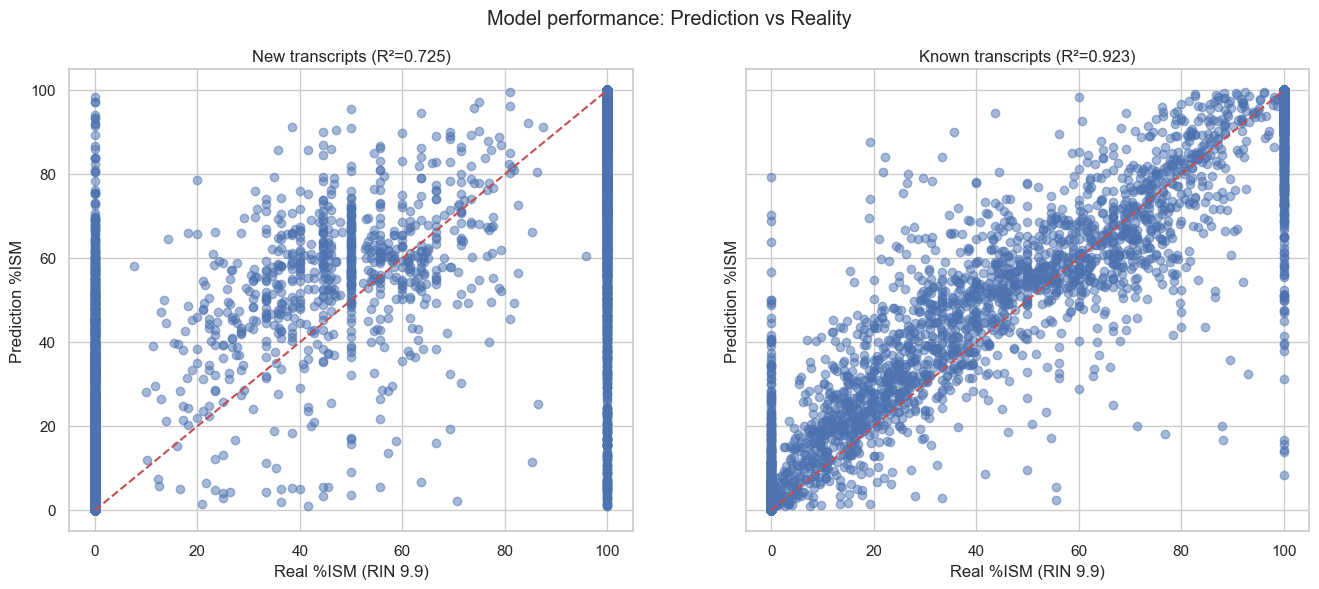

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

predicciones_vistos = mejor_modelo.predict(X_test_vistos)
print("\n--- TEST: TRANSCRITOS QUE YA ESTABAN EN EL TRAINING SET")
print("MAE:", mean_absolute_error(y_test_vistos, predicciones_vistos))
print("RMSE:", mean_squared_error(y_test_vistos, predicciones_vistos))
print("R²:", r2_score(y_test_vistos, predicciones_vistos))

predicciones_nuevos = mejor_modelo.predict(X_test_nuevos)
print("\n--- TEST: TRANSCRITOS QUE NO ESTABAN EN EL TRAINING SET")
print("MAE:", mean_absolute_error(y_test_nuevos, predicciones_nuevos))
print("RMSE:", mean_squared_error(y_test_nuevos, predicciones_nuevos))
print("R²:", r2_score(y_test_nuevos, predicciones_nuevos))

# Guardar los datos finales (X_test, y_test, predicciones) en un CSV o parquet
# Unir las predicciones a los dataframes originales para guardarlos
df_resultados_vistos = X_test_vistos.copy()
df_resultados_vistos['porc_ISM_real'] = y_test_vistos
df_resultados_vistos['prediccion'] = predicciones_vistos

df_resultados_nuevos = X_test_nuevos.copy()
df_resultados_nuevos['porc_ISM_real'] = y_test_nuevos
df_resultados_nuevos['prediccion'] = predicciones_nuevos

import matplotlib.pyplot as plt
n=0
for ax, i in zip(axes,[(y_test_nuevos,predicciones_nuevos),(y_test_vistos,predicciones_vistos)]):
    ax.scatter(i[0], i[1], alpha=0.5)
    ax.plot([i[0].min(), i[0].max()], [i[0].min(), i[0].max()], 'r--')
    ax.set_xlabel("Real %ISM (RIN 9.9)")
    ax.set_ylabel("Prediction %ISM")
    ax.set_title(f"New transcripts (R²={r2_score(y_test_nuevos, predicciones_nuevos):.3f})" if n==0 else f"Known transcripts (R²={r2_score(y_test_vistos, predicciones_vistos):.3f})")
    n+=1
fig.suptitle("Model performance: Prediction vs Reality")


--- FEATURE IMPORTANCES ---
                    Feature  Importance
82     avg_diff_to_gene_TSS    0.385243
2                 ref_exons    0.178279
84  avg_CV_diff_to_gene_TSS    0.126029
8     exon_junction_density    0.059274
11               length_CDS    0.024474
81               avg_length    0.023437
87               avg_Cov_D2    0.022840
6              dip_test_TSS    0.012466
7         dip_test_TSS_pval    0.009890
1                ref_length    0.008995
86               avg_Cov_D1    0.008438
15             length_5pUTR    0.007466
9                   porc_GC    0.007249
88               avg_Cov_D3    0.006118
13             length_3pUTR    0.005805
5                       RIN    0.004402
83     avg_diff_to_gene_TTS    0.004015
95              avg_Cov_D10    0.003299
14            porc_GC_3pUTR    0.003231
26                codon_ATC    0.003074
27                codon_ATT    0.002538
16            porc_GC_5pUTR    0.002514
10           CPM_transcript    0.002475
17          

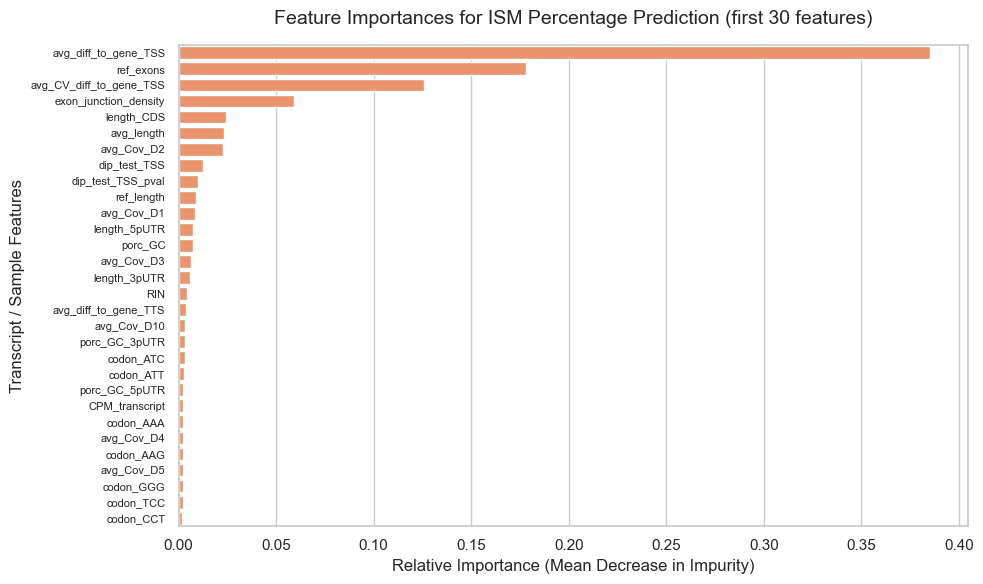

In [282]:
import seaborn as sns
importancias = mejor_modelo.feature_importances_
nombres_columnas = X_test_vistos.columns

# 2. Crear un DataFrame y ordenarlo de mayor a menor
df_importancias = pd.DataFrame({
    'Feature': nombres_columnas,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False).head(30)

# Mostrar el top en texto por consola
print("--- FEATURE IMPORTANCES ---")
print(df_importancias)

# 3. Plotear un gráfico de barras horizontal (es el formato más legible)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Usamos un paleta de colores degradada para que quede profesional
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importancias, 
    color="#fc8d59" # O 'viridis', 'crest', etc.
)
plt.yticks(fontsize=8)
plt.title('Feature Importances for ISM Percentage Prediction (first 30 features)', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Transcript / Sample Features', fontsize=12)
plt.tight_layout()


plt.show()